# BR-101 EDA Runbook: Steps 1-6

This notebook implements the first six steps from
`documentation/eda-runbook.md`:
1. Standardize PRF occurrence tables.
2. Build the canonical BR-101 spatial corridor.
3. Build municipality and RGI attribution layers.
4. Define the canonical accident set.
5. Attribute accidents to municipality and RGI.
6. Produce coverage diagnostics and manual-review artifacts.

The default implementation follows the runbook decisions already stated there:
- canonical corridor = union of the 2017, 2021, and 2026 DNIT BR-101 buffers
- canonical accident policy = strict `declared_and_inside`
- territorial truth = official IBGE polygons only
- exclusions are manual/visual review only
- 2026 is retained in descriptive EDA outputs

In [1]:
from __future__ import annotations
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from shapely import intersects_xy
from shapely.ops import unary_union
from IPython.display import display

pd.set_option("display.max_columns", None)

BR101_UFS = {"PB", "BA", "PR", "AL", "PE", "ES", "RN", "RS", "SC", "SE", "SP", "RJ"}
GEODETIC_CRS = "EPSG:4674"
PROJECTED_CRS = "EPSG:5880"
CORRIDOR_BUFFER_METERS = 500


def resolve_project_root() -> Path:
    candidates: list[Path] = []
    if "__file__" in globals():
        candidates.append(Path(__file__).resolve().parents[1])

    cwd = Path.cwd().resolve()
    candidates.extend([cwd, cwd.parent])

    for candidate in candidates:
        if (candidate / "pyproject.toml").exists() and (candidate / "data").exists():
            return candidate

    raise FileNotFoundError("Could not resolve the project root.")


PROJECT_ROOT = resolve_project_root()
BRONZE_DIR = PROJECT_ROOT / "data" / "bronze"
ARTIFACTS_DIR = PROJECT_ROOT / "data" / "silver" / "eda_runbook"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

OCCURRENCE_GLOB = "*Agrupados por ocorrência*.csv.gz"
DNIT_FILES = {
    2017: BRONZE_DIR / "201703A.zip",
    2021: BRONZE_DIR / "202107A.zip",
    2026: BRONZE_DIR / "202601A.zip",
}
MUNICIPALITIES_PATH = BRONZE_DIR / "BR_Municipios_2024.zip"
RGI_PATH = BRONZE_DIR / "BR_RG_Imediatas_2024.zip"

sns.set_theme(style="whitegrid")


def normalize_numeric(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")

    cleaned = (
        series.astype("string")
        .str.strip()
        .str.replace(",", ".", regex=False)
        .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
    )
    return pd.to_numeric(cleaned, errors="coerce")


def canonicalize_road_code(series: pd.Series) -> pd.Series:
    extracted = series.astype("string").str.extract(r"(\d+)", expand=False)
    stripped = extracted.str.lstrip("0")
    return stripped.replace("", pd.NA)


def prepare_week_start(timestamp: pd.Series) -> pd.Series:
    return timestamp.dt.to_period("W-SUN").dt.start_time


def assign_accident_class(df: pd.DataFrame) -> pd.Series:
    has_valid_coords = df["has_valid_coords"].fillna(False).to_numpy(dtype=bool)
    is_br101_declared = df["is_br101_declared"].fillna(False).to_numpy(dtype=bool)
    inside_canonical_corridor = df["inside_canonical_corridor"].fillna(False).to_numpy(dtype=bool)

    conditions = [
        ~has_valid_coords,
        is_br101_declared & inside_canonical_corridor,
        is_br101_declared & ~inside_canonical_corridor,
        ~is_br101_declared & inside_canonical_corridor,
    ]
    choices = [
        "missing_or_invalid_coords",
        "declared_and_inside",
        "declared_outside",
        "undeclared_inside",
    ]
    return pd.Series(np.select(conditions, choices, default="outside_all"), index=df.index)


def keep_line_geometries(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    line_types = {"LineString", "MultiLineString"}
    filtered = gdf.loc[gdf.geometry.geom_type.isin(line_types)].copy()
    return filtered.loc[filtered.geometry.length > 0].copy()


def save_frame(df: pd.DataFrame, name: str, *, index: bool = False) -> None:
    parquet_path = ARTIFACTS_DIR / f"{name}.parquet"
    csv_path = ARTIFACTS_DIR / f"{name}.csv"
    df.to_parquet(parquet_path, index=index)
    df.to_csv(csv_path, index=index)


def save_geoframe(gdf: gpd.GeoDataFrame, name: str) -> None:
    parquet_path = ARTIFACTS_DIR / f"{name}.parquet"
    gdf.to_parquet(parquet_path, index=False)


def drop_spatial_join_index_columns(df: pd.DataFrame) -> pd.DataFrame:
    columns_to_drop = [
        column
        for column in df.columns
        if column == "index_right" or column.startswith("index_right_")
    ]
    return df.drop(columns=columns_to_drop, errors="ignore")


def load_filtered_dnit_snapshot(snapshot_year: int, path: Path) -> gpd.GeoDataFrame:
    cache_path = ARTIFACTS_DIR / f"_cache_br101_snapshot_{snapshot_year}.parquet"
    if cache_path.exists():
        return gpd.read_parquet(cache_path).to_crs(PROJECTED_CRS)

    dnit = gpd.read_file(path, columns=["vl_br", "sg_uf", "versao_snv", "geometry"])
    dnit["br_canonical"] = canonicalize_road_code(dnit["vl_br"])
    dnit = dnit.loc[dnit["br_canonical"].eq("101"), ["sg_uf", "versao_snv", "geometry"]].copy()
    dnit = dnit.to_crs(PROJECTED_CRS)
    dnit["snapshot_year"] = snapshot_year
    dnit.to_parquet(cache_path, index=False)
    return dnit

## Step 1. Standardize PRF occurrence tables

In [2]:
occurrence_files = sorted(BRONZE_DIR.glob(OCCURRENCE_GLOB))
occurrence_files

[PosixPath('/home/arthur/Documents/projects/radar-prf-101/data/bronze/2017_Agrupados por ocorrência.csv.gz'),
 PosixPath('/home/arthur/Documents/projects/radar-prf-101/data/bronze/2018_Agrupados por ocorrência.csv.gz'),
 PosixPath('/home/arthur/Documents/projects/radar-prf-101/data/bronze/2019_Agrupados por ocorrência.csv.gz'),
 PosixPath('/home/arthur/Documents/projects/radar-prf-101/data/bronze/2020_Agrupados por ocorrência.csv.gz'),
 PosixPath('/home/arthur/Documents/projects/radar-prf-101/data/bronze/2021_Agrupados por ocorrência.csv.gz'),
 PosixPath('/home/arthur/Documents/projects/radar-prf-101/data/bronze/2022_Agrupados por ocorrência.csv.gz'),
 PosixPath('/home/arthur/Documents/projects/radar-prf-101/data/bronze/2023_Agrupados por ocorrência.csv.gz'),
 PosixPath('/home/arthur/Documents/projects/radar-prf-101/data/bronze/2024_Agrupados por ocorrência.csv.gz'),
 PosixPath('/home/arthur/Documents/projects/radar-prf-101/data/bronze/2025_Agrupados por ocorrência.csv.gz'),
 PosixPath

In [3]:
occurrence_frames: list[pd.DataFrame] = []
for path in occurrence_files:
    frame = pd.read_csv(path, compression="gzip")
    frame["source_year_file"] = int(path.name[:4])
    occurrence_frames.append(frame)

occ_raw = pd.concat(occurrence_frames, ignore_index=True)
print(f"Loaded {len(occ_raw):,} occurrence rows from {len(occurrence_files)} files.")

Loaded 638,468 occurrence rows from 10 files.


In [4]:
occ = occ_raw.copy()
occ["uf"] = occ["uf"].astype("string").str.upper().str.strip()
occ["municipio"] = occ["municipio"].astype("string").str.strip()
occ["km"] = normalize_numeric(occ["km"])
occ["latitude"] = normalize_numeric(occ["latitude"])
occ["longitude"] = normalize_numeric(occ["longitude"])
for numeric_column in [
    "id",
    "pessoas",
    "mortos",
    "feridos_leves",
    "feridos_graves",
    "ilesos",
    "ignorados",
    "feridos",
    "veiculos",
]:
    occ[numeric_column] = normalize_numeric(occ[numeric_column])

occ["br_canonical"] = canonicalize_road_code(occ["br"])
occ["is_br101_declared"] = occ["br_canonical"].eq("101")

occ["timestamp"] = pd.to_datetime(
    occ["data_inversa"].astype("string").str.strip()
    + " "
    + occ["horario"].astype("string").str.strip(),
    errors="coerce",
)
occ["year"] = occ["timestamp"].dt.year
occ["month"] = occ["timestamp"].dt.month
occ["quarter"] = occ["timestamp"].dt.quarter
occ["week_start"] = prepare_week_start(occ["timestamp"])
occ["fatal_victims_occ"] = pd.to_numeric(occ["mortos"], errors="coerce").fillna(0).astype(int)
occ["has_valid_timestamp"] = occ["timestamp"].notna()

# TODO: use statistical/geographical methods to identify outliers instead of hardcoded bounds
brazil_bounds = {
    "lat_min": -35.0,
    "lat_max": 6.0,
    "lon_min": -75.0,
    "lon_max": -28.0,
}
occ["has_valid_coords"] = (
    occ["latitude"].between(brazil_bounds["lat_min"], brazil_bounds["lat_max"], inclusive="both")
    & occ["longitude"].between(brazil_bounds["lon_min"], brazil_bounds["lon_max"], inclusive="both")
)
occ.loc[~occ["has_valid_coords"], ["latitude", "longitude"]] = np.nan

occ_standardized = occ.copy()
save_frame(occ_standardized, "occurrence_standardized")

print(f"Standardized occurrence table has {len(occ_standardized):,} rows and {occ_standardized.shape[1]} columns.")

occ_standardized.head()

Standardized occurrence table has 638,468 rows and 41 columns.


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,source_year_file,br_canonical,is_br101_declared,timestamp,year,month,quarter,week_start,fatal_victims_occ,has_valid_timestamp,has_valid_coords
0,17.0,2017-01-01,domingo,01:45:00,RS,116,34.9,VACARIA,Defeito Mecânico no Veículo,Colisão traseira,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Reta,Não,6,0,4,0,2,0,4,2,-28.50712,-50.941176,SPRF-RS,DEL05-RS,UOP03-DEL05-RS,2017,116,False,2017-01-01 01:45:00,2017,1,1,2016-12-26,0,True,True
1,20.0,2017-01-01,domingo,01:00:00,PR,376,636.0,TIJUCAS DO SUL,Velocidade Incompatível,Saída de leito carroçável,Com Vítimas Fatais,Plena Noite,Crescente,Garoa/Chuvisco,Dupla,Curva,Não,2,1,0,0,1,0,0,2,-25.754,-49.1266,SPRF-PR,DEL01-PR,DEL7/1-UOP08/PR,2017,376,False,2017-01-01 01:00:00,2017,1,1,2016-12-26,1,True,True
2,69.0,2017-01-01,domingo,04:40:00,BA,101,65.0,ENTRE RIOS,Condutor Dormindo,Colisão frontal,Com Vítimas Fatais,Amanhecer,Decrescente,Nublado,Simples,Curva,Não,5,1,1,1,2,0,2,2,-11.9618,-38.0953,SPRF-BA,DEL01-BA,UOP04-DEL01-BA,2017,101,True,2017-01-01 04:40:00,2017,1,1,2016-12-26,1,True,True
3,106.0,2017-01-01,domingo,06:30:00,PA,316,72.5,CASTANHAL,Falta de Atenção à Condução,Colisão lateral,Com Vítimas Fatais,Amanhecer,Decrescente,Céu Claro,Simples,Reta,Não,4,1,0,0,3,0,0,3,-1.28998,-47.834832,SPRF-PA,DEL01-PA,DEL19/1-UOP02/PA,2017,316,False,2017-01-01 06:30:00,2017,1,1,2016-12-26,1,True,True
4,109.0,2017-01-01,domingo,09:00:00,GO,20,220.5,POSSE,Defeito na Via,Colisão com objeto estático,NaN,Pleno dia,Decrescente,Céu Claro,Simples,Declive,Não,4,0,2,1,0,1,3,2,-14.142209,-46.322589,SPRF-DF,DEL02-DF,UOP03-DEL02-DF,2017,20,False,2017-01-01 09:00:00,2017,1,1,2016-12-26,0,True,True


## Step 2. Build the canonical BR-101 spatial corridor

In [5]:
step2_paths = {
    "centerlines": ARTIFACTS_DIR / "br101_centerlines_by_snapshot.parquet",
    "corridors": ARTIFACTS_DIR / "br101_corridors_by_snapshot.parquet",
    "road_union": ARTIFACTS_DIR / "br101_centerline_union.parquet",
    "corridor_union": ARTIFACTS_DIR / "br101_corridor_union.parquet",
}

if all(path.exists() for path in step2_paths.values()):
    yearly_centerlines_proj_gdf = gpd.read_parquet(step2_paths["centerlines"]).to_crs(PROJECTED_CRS)
    yearly_corridors_proj_gdf = gpd.read_parquet(step2_paths["corridors"]).to_crs(PROJECTED_CRS)
    road_union_gdf = gpd.read_parquet(step2_paths["road_union"]).to_crs(PROJECTED_CRS)
    corridor_union_gdf = gpd.read_parquet(step2_paths["corridor_union"]).to_crs(PROJECTED_CRS)
else:
    yearly_centerlines_proj: list[gpd.GeoDataFrame] = []
    yearly_corridors_proj: list[gpd.GeoDataFrame] = []

    for snapshot_year, path in DNIT_FILES.items():
        dnit = load_filtered_dnit_snapshot(snapshot_year, path)

        centerline = dnit[["snapshot_year", "geometry"]].dissolve(by="snapshot_year", as_index=False)
        centerline["geometry_type"] = centerline.geometry.geom_type
        yearly_centerlines_proj.append(centerline)

        corridor = centerline[["snapshot_year", "geometry"]].copy()
        corridor["geometry"] = corridor.geometry.buffer(CORRIDOR_BUFFER_METERS)
        corridor["corridor_area_km2"] = corridor.geometry.area / 1_000_000
        yearly_corridors_proj.append(corridor)

    yearly_centerlines_proj_gdf = gpd.GeoDataFrame(
        pd.concat(yearly_centerlines_proj, ignore_index=True),
        geometry="geometry",
        crs=PROJECTED_CRS,
    )
    yearly_corridors_proj_gdf = gpd.GeoDataFrame(
        pd.concat(yearly_corridors_proj, ignore_index=True),
        geometry="geometry",
        crs=PROJECTED_CRS,
    )

    road_union_geom_proj = unary_union(yearly_centerlines_proj_gdf.geometry.tolist())
    corridor_union_geom_proj = unary_union(yearly_corridors_proj_gdf.geometry.tolist())

    road_union_gdf = gpd.GeoDataFrame(
        {"corridor_policy": ["union_all_years"], "geometry": [road_union_geom_proj]},
        geometry="geometry",
        crs=PROJECTED_CRS,
    )
    corridor_union_gdf = gpd.GeoDataFrame(
        {
            "corridor_policy": ["union_all_years"],
            "buffer_meters": [CORRIDOR_BUFFER_METERS],
            "geometry": [corridor_union_geom_proj],
        },
        geometry="geometry",
        crs=PROJECTED_CRS,
    )
    corridor_union_gdf["corridor_area_km2"] = corridor_union_gdf.geometry.area / 1_000_000

    save_geoframe(yearly_centerlines_proj_gdf.to_crs(GEODETIC_CRS), "br101_centerlines_by_snapshot")
    save_geoframe(yearly_corridors_proj_gdf.to_crs(GEODETIC_CRS), "br101_corridors_by_snapshot")
    save_geoframe(road_union_gdf.to_crs(GEODETIC_CRS), "br101_centerline_union")
    save_geoframe(corridor_union_gdf.to_crs(GEODETIC_CRS), "br101_corridor_union")

road_union_geom_proj = road_union_gdf.geometry.iloc[0]
corridor_union_geom_proj = corridor_union_gdf.geometry.iloc[0]

corridor_union_gdf.to_crs(GEODETIC_CRS)

,corridor_policy,buffer_meters,geometry,corridor_area_km2
0,union_all_years,500,"MULTIPOLYGON (((-52.07203 -32.04871, -52.07203...",4900.847565


## Step 3. Build municipality and RGI attribution layers

In [6]:
gdf_mun = gpd.read_file(MUNICIPALITIES_PATH)
gdf_rgi = gpd.read_file(RGI_PATH)

gdf_mun = gdf_mun.loc[gdf_mun["SIGLA_UF"].isin(BR101_UFS)].copy()
gdf_rgi = gdf_rgi.loc[gdf_rgi["SIGLA_UF"].isin(BR101_UFS)].copy()

gdf_mun_proj = gdf_mun.to_crs(PROJECTED_CRS)
gdf_rgi_proj = gdf_rgi.to_crs(PROJECTED_CRS)

retained_mun_proj = gdf_mun_proj.loc[gdf_mun_proj.geometry.intersects(corridor_union_geom_proj)].copy()
retained_rgi_proj = gdf_rgi_proj.loc[gdf_rgi_proj.geometry.intersects(corridor_union_geom_proj)].copy()

retained_mun_proj["polygon_area_km2"] = retained_mun_proj.geometry.area / 1_000_000
retained_rgi_proj["polygon_area_km2"] = retained_rgi_proj.geometry.area / 1_000_000

mun_sections_proj = retained_mun_proj[
    ["CD_MUN", "NM_MUN", "CD_RGI", "NM_RGI", "SIGLA_UF", "geometry"]
].copy()
mun_sections_proj["geometry"] = mun_sections_proj.geometry.intersection(road_union_geom_proj)
mun_sections_proj = mun_sections_proj.loc[~mun_sections_proj.geometry.is_empty].copy()
mun_sections_proj = gpd.GeoDataFrame(mun_sections_proj, geometry="geometry", crs=PROJECTED_CRS)
mun_sections_proj = mun_sections_proj.explode(index_parts=False).reset_index(drop=True)
mun_sections_proj = keep_line_geometries(mun_sections_proj)
mun_sections_proj["road_length_m"] = mun_sections_proj.geometry.length
mun_sections_proj["section_id"] = "mun_" + mun_sections_proj.index.astype(str).str.zfill(5)

rgi_sections_proj = retained_rgi_proj[
    ["CD_RGI", "NM_RGI", "CD_RGINT", "NM_RGINT", "SIGLA_UF", "geometry"]
].copy()
rgi_sections_proj["geometry"] = rgi_sections_proj.geometry.intersection(road_union_geom_proj)
rgi_sections_proj = rgi_sections_proj.loc[~rgi_sections_proj.geometry.is_empty].copy()
rgi_sections_proj = gpd.GeoDataFrame(rgi_sections_proj, geometry="geometry", crs=PROJECTED_CRS)
rgi_sections_proj = rgi_sections_proj.explode(index_parts=False).reset_index(drop=True)
rgi_sections_proj = keep_line_geometries(rgi_sections_proj)
rgi_sections_proj["road_length_m"] = rgi_sections_proj.geometry.length
rgi_sections_proj["section_id"] = "rgi_" + rgi_sections_proj.index.astype(str).str.zfill(5)

save_geoframe(retained_mun_proj.to_crs(GEODETIC_CRS), "municipalities_in_scope")
save_geoframe(retained_rgi_proj.to_crs(GEODETIC_CRS), "rgis_in_scope")
save_geoframe(mun_sections_proj.to_crs(GEODETIC_CRS), "road_sections_by_municipality")
save_geoframe(rgi_sections_proj.to_crs(GEODETIC_CRS), "road_sections_by_rgi")

print(f"Municipalities retained: {len(retained_mun_proj):,}")
print(f"RGIs retained: {len(retained_rgi_proj):,}")

Municipalities retained: 263
RGIs retained: 53


## Step 4. Define the canonical accident set

In [7]:
corridor_union_geom_geodetic = corridor_union_gdf.to_crs(GEODETIC_CRS).geometry.iloc[0]

lon = occ_standardized["longitude"].to_numpy(dtype=float, copy=False)
lat = occ_standardized["latitude"].to_numpy(dtype=float, copy=False)
valid_coords_mask = occ_standardized["has_valid_coords"].fillna(False).to_numpy(dtype=bool)

minx, miny, maxx, maxy = corridor_union_geom_geodetic.bounds
bbox_candidate_mask = (
    valid_coords_mask
    & (lon >= minx)
    & (lon <= maxx)
    & (lat >= miny)
    & (lat <= maxy)
)

inside_canonical_corridor = np.zeros(len(occ_standardized), dtype=bool)
inside_canonical_corridor[bbox_candidate_mask] = intersects_xy(
    corridor_union_geom_geodetic,
    lon[bbox_candidate_mask],
    lat[bbox_candidate_mask],
)

classified_accidents = occ_standardized.copy()
classified_accidents["inside_canonical_corridor"] = inside_canonical_corridor
classified_accidents["accident_class"] = assign_accident_class(classified_accidents)
classified_accidents["review_candidate"] = classified_accidents["accident_class"].isin(
    ["declared_outside", "undeclared_inside", "missing_or_invalid_coords"]
)
classified_accidents["canonical_policy"] = "strict_declared_and_inside"
classified_accidents["is_canonical_br101"] = classified_accidents["accident_class"].eq(
    "declared_and_inside"
)

save_frame(classified_accidents, "accidents_classified")

manual_review_candidates = classified_accidents.loc[classified_accidents["review_candidate"]].copy()
save_frame(manual_review_candidates, "manual_review_candidates")

classified_accidents["accident_class"].value_counts(dropna=False).to_frame("rows")

,rows
accident_class,
outside_all,526220
declared_and_inside,106254
undeclared_inside,4617
declared_outside,1324
missing_or_invalid_coords,53


In [8]:
classified_accidents

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,source_year_file,br_canonical,is_br101_declared,timestamp,year,month,quarter,week_start,fatal_victims_occ,has_valid_timestamp,has_valid_coords,inside_canonical_corridor,accident_class,review_candidate,canonical_policy,is_canonical_br101
0,17.0,2017-01-01,domingo,01:45:00,RS,116,34.9,VACARIA,Defeito Mecânico no Veículo,Colisão traseira,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Reta,Não,6,0,4,0,2,0,4,2,-28.50712,-50.941176,SPRF-RS,DEL05-RS,UOP03-DEL05-RS,2017,116,False,2017-01-01 01:45:00,2017,1,1,2016-12-26,0,True,True,False,outside_all,False,strict_declared_and_inside,False
1,20.0,2017-01-01,domingo,01:00:00,PR,376,636.0,TIJUCAS DO SUL,Velocidade Incompatível,Saída de leito carroçável,Com Vítimas Fatais,Plena Noite,Crescente,Garoa/Chuvisco,Dupla,Curva,Não,2,1,0,0,1,0,0,2,-25.754,-49.1266,SPRF-PR,DEL01-PR,DEL7/1-UOP08/PR,2017,376,False,2017-01-01 01:00:00,2017,1,1,2016-12-26,1,True,True,False,outside_all,False,strict_declared_and_inside,False
2,69.0,2017-01-01,domingo,04:40:00,BA,101,65.0,ENTRE RIOS,Condutor Dormindo,Colisão frontal,Com Vítimas Fatais,Amanhecer,Decrescente,Nublado,Simples,Curva,Não,5,1,1,1,2,0,2,2,-11.9618,-38.0953,SPRF-BA,DEL01-BA,UOP04-DEL01-BA,2017,101,True,2017-01-01 04:40:00,2017,1,1,2016-12-26,1,True,True,True,declared_and_inside,False,strict_declared_and_inside,True
3,106.0,2017-01-01,domingo,06:30:00,PA,316,72.5,CASTANHAL,Falta de Atenção à Condução,Colisão lateral,Com Vítimas Fatais,Amanhecer,Decrescente,Céu Claro,Simples,Reta,Não,4,1,0,0,3,0,0,3,-1.28998,-47.834832,SPRF-PA,DEL01-PA,DEL19/1-UOP02/PA,2017,316,False,2017-01-01 06:30:00,2017,1,1,2016-12-26,1,True,True,False,outside_all,False,strict_declared_and_inside,False
4,109.0,2017-01-01,domingo,09:00:00,GO,20,220.5,POSSE,Defeito na Via,Colisão com objeto estático,NaN,Pleno dia,Decrescente,Céu Claro,Simples,Declive,Não,4,0,2,1,0,1,3,2,-14.142209,-46.322589,SPRF-DF,DEL02-DF,UOP03-DEL02-DF,2017,20,False,2017-01-01 09:00:00,2017,1,1,2016-12-26,0,True,True,False,outside_all,False,strict_declared_and_inside,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
638463,754770.0,2026-01-26,segunda-feira,04:20:00,RJ,465,22.0,RIO DE JANEIRO,Demais falhas mecânicas ou elétricas,Incêndio,Sem Vítimas,Amanhecer,Crescente,Céu Claro,Simples,Reta,Sim,1,0,0,0,1,0,0,1,-22.860609,-43.601643,SPRF-RJ,DEL03-RJ,UOP01-DEL03-RJ,2026,465,False,2026-01-26 04:20:00,2026,1,1,2026-01-26,0,True,True,False,outside_all,False,strict_declared_and_inside,False
638464,754809.0,2026-01-16,sexta-feira,02:20:00,PA,230,310.7,NOVO PROGRESSO,Ausência de reação do condutor,Colisão com objeto,Com Vítimas Feridas,Plena Noite,Decrescente,Ignorado,Simples,Reta,Sim,1,0,0,1,0,0,1,1,-7.040544,-55.414782,SPRF-PA,DEL03-PA,UOP01-DEL03-PA,2026,230,False,2026-01-16 02:20:00,2026,1,1,2026-01-12,0,True,True,False,outside_all,False,strict_declared_and_inside,False
638465,754975.0,2026-01-24,sábado,07:30:00,RJ,101,310.0,SAO GONCALO,Mal súbito do condutor,Saída de leito carroçável,Com Vítimas Feridas,Amanhecer,Crescente,Chuva,Dupla,Reta,Sim,1,0,1,0,0,0,1,1,-22.834659,-43.096431,SPRF-RJ,DEL02-RJ,UOP02-DEL02-RJ,2026,101,True,2026-01-24 07:30:00,2026,1,1,2026-01-19,0,True,True,True,declared_and_inside,False,strict_declared_and_inside,True
638466,755002.0,2026-01-10,sábado,17:50:00,RJ,101,468.0,ANGRA DOS REIS,Reação tardia ou ineficiente do condutor,Colisão transversal,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Simples,Curva,Não,9,0,7,1,1,0,8,2,-23.0077,-44.224091,SPRF-RJ,DEL03-RJ,UOP03-DEL03-RJ,2026,101,True,2026-01-10 17:50:00,2026,1,1,2026-01-05,0,T

## Step 5. Attribute canonical accidents to municipality and RGI

In [9]:
canonical_accidents = classified_accidents.loc[classified_accidents["is_canonical_br101"]].copy()
canonical_accidents_gdf = gpd.GeoDataFrame(
    canonical_accidents,
    geometry=gpd.points_from_xy(canonical_accidents["longitude"], canonical_accidents["latitude"]),
    crs=GEODETIC_CRS,
)

mun_assign = gpd.sjoin(
    canonical_accidents_gdf,
    retained_mun_proj.to_crs(GEODETIC_CRS)[["CD_MUN", "NM_MUN", "CD_RGI", "NM_RGI", "SIGLA_UF", "geometry"]],
    how="left",
    predicate="within",
)
mun_assign = drop_spatial_join_index_columns(mun_assign)
mun_assign["municipality_match_status"] = np.where(
    mun_assign["CD_MUN"].notna(), "matched_exact_polygon", "unmatched_exact_polygon"
)

rgi_assign = gpd.sjoin(
    mun_assign,
    retained_rgi_proj.to_crs(GEODETIC_CRS)[["CD_RGI", "NM_RGI", "CD_RGINT", "NM_RGINT", "SIGLA_UF", "geometry"]],
    how="left",
    predicate="within",
    lsuffix="mun",
    rsuffix="rgi",
)
rgi_assign = drop_spatial_join_index_columns(rgi_assign)
rgi_assign["rgi_match_status"] = np.where(
    rgi_assign["CD_RGI_rgi"].notna(), "matched_exact_polygon", "unmatched_exact_polygon"
)
rgi_assign["assignment_rule"] = "official_polygon_exact"
rgi_assign["depends_on_tolerant_geometry"] = False

final_columns = [
    "id",
    "timestamp",
    "data_inversa",
    "horario",
    "year",
    "month",
    "quarter",
    "week_start",
    "uf",
    "municipio",
    "br",
    "br_canonical",
    "km",
    "latitude",
    "longitude",
    "dia_semana",
    "fase_dia",
    "condicao_metereologica",
    "tipo_acidente",
    "classificacao_acidente",
    "pessoas",
    "mortos",
    "fatal_victims_occ",
    "inside_canonical_corridor",
    "accident_class",
    "canonical_policy",
    "CD_MUN",
    "NM_MUN",
    "CD_RGI_mun",
    "NM_RGI_mun",
    "CD_RGI_rgi",
    "NM_RGI_rgi",
    "CD_RGINT",
    "NM_RGINT",
    "municipality_match_status",
    "rgi_match_status",
    "assignment_rule",
    "depends_on_tolerant_geometry",
    "geometry",
]
canonical_accidents_gdf = rgi_assign[final_columns].copy()
canonical_accidents_gdf = canonical_accidents_gdf.rename(
    columns={
        "CD_RGI_mun": "CD_RGI_from_municipality",
        "NM_RGI_mun": "NM_RGI_from_municipality",
        "CD_RGI_rgi": "CD_RGI",
        "NM_RGI_rgi": "NM_RGI",
    }
)

unmatched_assignments = canonical_accidents_gdf.loc[
    canonical_accidents_gdf["municipality_match_status"].ne("matched_exact_polygon")
    | canonical_accidents_gdf["rgi_match_status"].ne("matched_exact_polygon")
].copy()

save_geoframe(canonical_accidents_gdf, "canonical_accidents_geospatial")
save_frame(canonical_accidents_gdf.drop(columns="geometry"), "canonical_accidents")
save_frame(unmatched_assignments.drop(columns="geometry"), "canonical_accidents_unmatched_assignments")

canonical_accidents_gdf[
    ["municipality_match_status", "rgi_match_status"]
].value_counts(dropna=False).to_frame("rows")

,,rows
municipality_match_status,rgi_match_status,
matched_exact_polygon,matched_exact_polygon,105342
unmatched_exact_polygon,unmatched_exact_polygon,912


## Step 6. Coverage checks and exclusion-review artifacts

In [25]:
coverage_review = (
    classified_accidents.groupby(["uf", "year"], dropna=False)
    .agg(
        total_cases=("id", "size"),
        fatal_victims_occ=("fatal_victims_occ", "sum"),
        total_people_involved=("pessoas", "sum"),
        missing_coords_cases=("has_valid_coords", lambda s: (~s).sum()),
        declared_br101_cases=("is_br101_declared", "sum"),
        declared_br101_outside_corridor=(
            "accident_class",
            lambda s: s.eq("declared_outside").sum(),
        ),
        canonical_cases=("is_canonical_br101", "sum"),
    )
    .reset_index()
    .sort_values(["uf", "year"])
)

coverage_review["missing_coords_share"] = (
    coverage_review["missing_coords_cases"] / coverage_review["total_cases"]
)
coverage_review["declared_br101_outside_corridor_share"] = np.where(
    coverage_review["declared_br101_cases"] > 0,
    coverage_review["declared_br101_outside_corridor"] / coverage_review["declared_br101_cases"],
    np.nan,
)
coverage_review["cases_pct_change_vs_prev_year"] = coverage_review.groupby("uf")["total_cases"].pct_change()
coverage_review["fatal_pct_change_vs_prev_year"] = coverage_review.groupby("uf")[
    "fatal_victims_occ"
].pct_change()
coverage_review["is_partial_year"] = coverage_review["year"].eq(2026)
coverage_review["review_rule"] = "manual_visual_review_only"

MANUAL_EXCLUDED_UFS = {"SP", "RS"}
coverage_review["exclude_from_descriptive"] = coverage_review["uf"].isin(MANUAL_EXCLUDED_UFS)
coverage_review["exclude_from_modeling"] = coverage_review["uf"].isin(MANUAL_EXCLUDED_UFS)

save_frame(coverage_review, "coverage_review_uf_year")

manual_exclusions = coverage_review[["uf", "year"]].copy()
manual_exclusions["reason"] = np.where(
    manual_exclusions["uf"].isin(MANUAL_EXCLUDED_UFS),
    "Excessive missing spatial coverage in point map (manual visual review).",
    "",
)
manual_exclusions["evidence"] = np.where(
    manual_exclusions["uf"].isin(MANUAL_EXCLUDED_UFS),
    "Coverage point plot indicates clear undercoverage/missingness.",
    "",
)
manual_exclusions["exclude_from_descriptive"] = manual_exclusions["uf"].isin(MANUAL_EXCLUDED_UFS)
manual_exclusions["exclude_from_modeling"] = manual_exclusions["uf"].isin(MANUAL_EXCLUDED_UFS)

save_frame(manual_exclusions, "manual_exclusions")

coverage_review.head(20)

,uf,year,total_cases,fatal_victims_occ,total_people_involved,missing_coords_cases,declared_br101_cases,declared_br101_outside_corridor,canonical_cases,missing_coords_share,declared_br101_outside_corridor_share,cases_pct_change_vs_prev_year,fatal_pct_change_vs_prev_year,is_partial_year,review_rule,exclude_from_descriptive,exclude_from_modeling
0,AC,2017,304,18,803,0,0,0,0,0.0,NaN,NaN,NaN,False,manual_visual_review_only,False,False
1,AC,2018,238,26,648,0,0,0,0,0.0,NaN,-0.217105,0.444444,False,manual_visual_review_only,False,False
2,AC,2019,262,24,631,0,0,0,0,0.0,NaN,0.100840,-0.076923,False,manual_visual_review_only,False,False
3,AC,2020,300,13,673,0,0,0,0,0.0,NaN,0.145038,-0.458333,False,manual_visual_review_only,False,False
4,AC,2021,256,22,600,0,0,0,0,0.0,NaN,-0.146667,0.692308,False,manual_visual_review_only,False,False
5,AC,2022,224,18,567,0,0,0,0,0.0,NaN,-0.125000,-0.181818,False,manual_visual_review_only,False,False
6,AC,2023,225,24,556,0,0,0,0,0.0,NaN,0.004464,0.333333,False,manual_visual_review_only,False,False
7,AC,2024,287,20,735,0,0,0,0,0.0,NaN,0.275556,-0.166667,False,manual_visual_review_only,False,False
8,AC,2025,280,29,702,0,0,0,0,0.0,NaN,-0.024390,0.450000,False,manual_visual_review_only,False,False
9,AC,2026,20,4,44,0,0,0,0,0.0,NaN,-0.928571,-0.862069,True,manual_visual_review_only,False,False


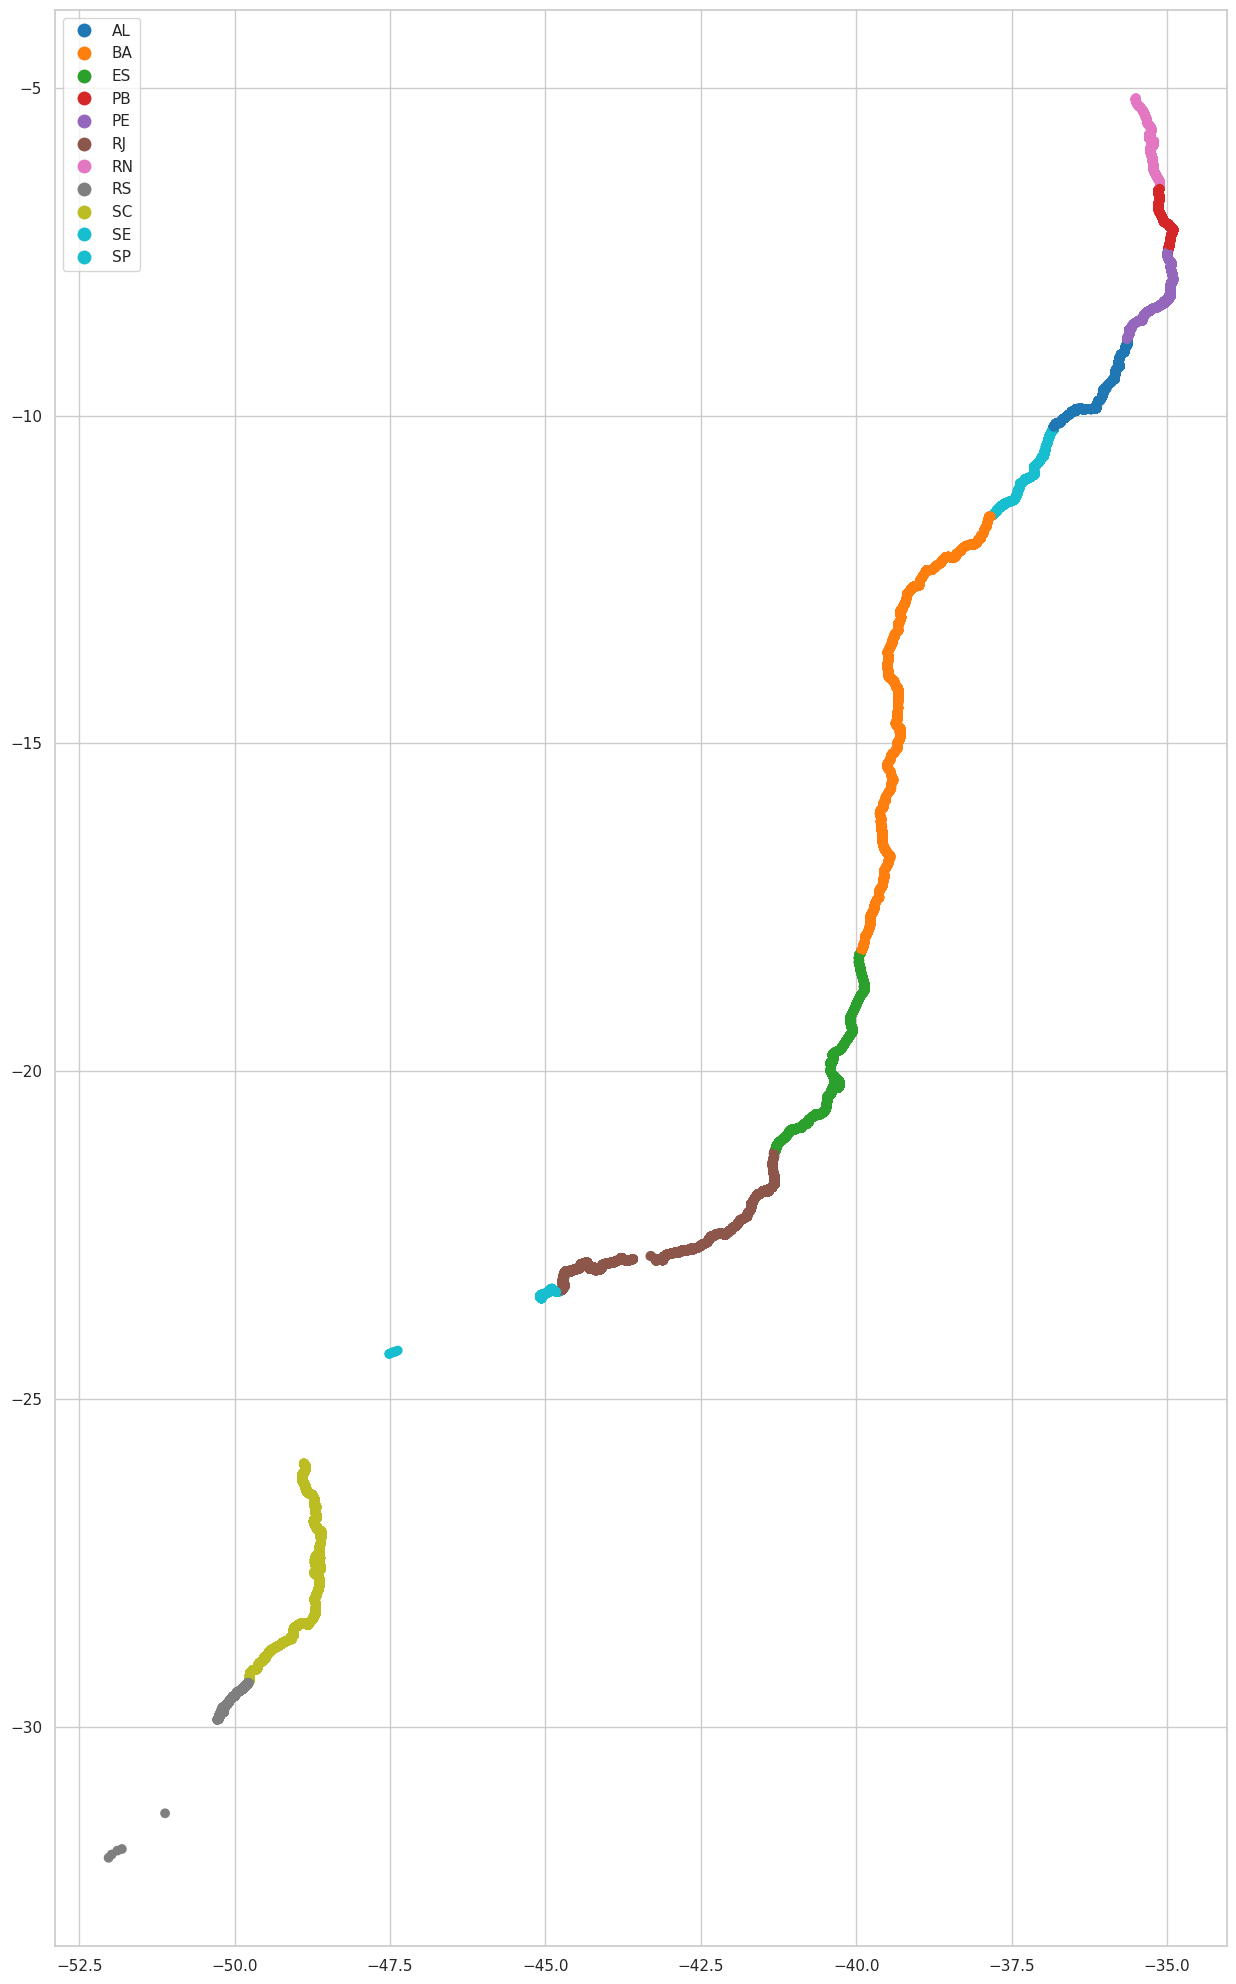

In [24]:
fig, ax = plt.subplots(figsize=(30, 20))
canonical_accidents_gdf.plot(
    column="uf",
    categorical=True,
    legend=True,
    ax=ax,
)

plt.tight_layout()
plt.show()

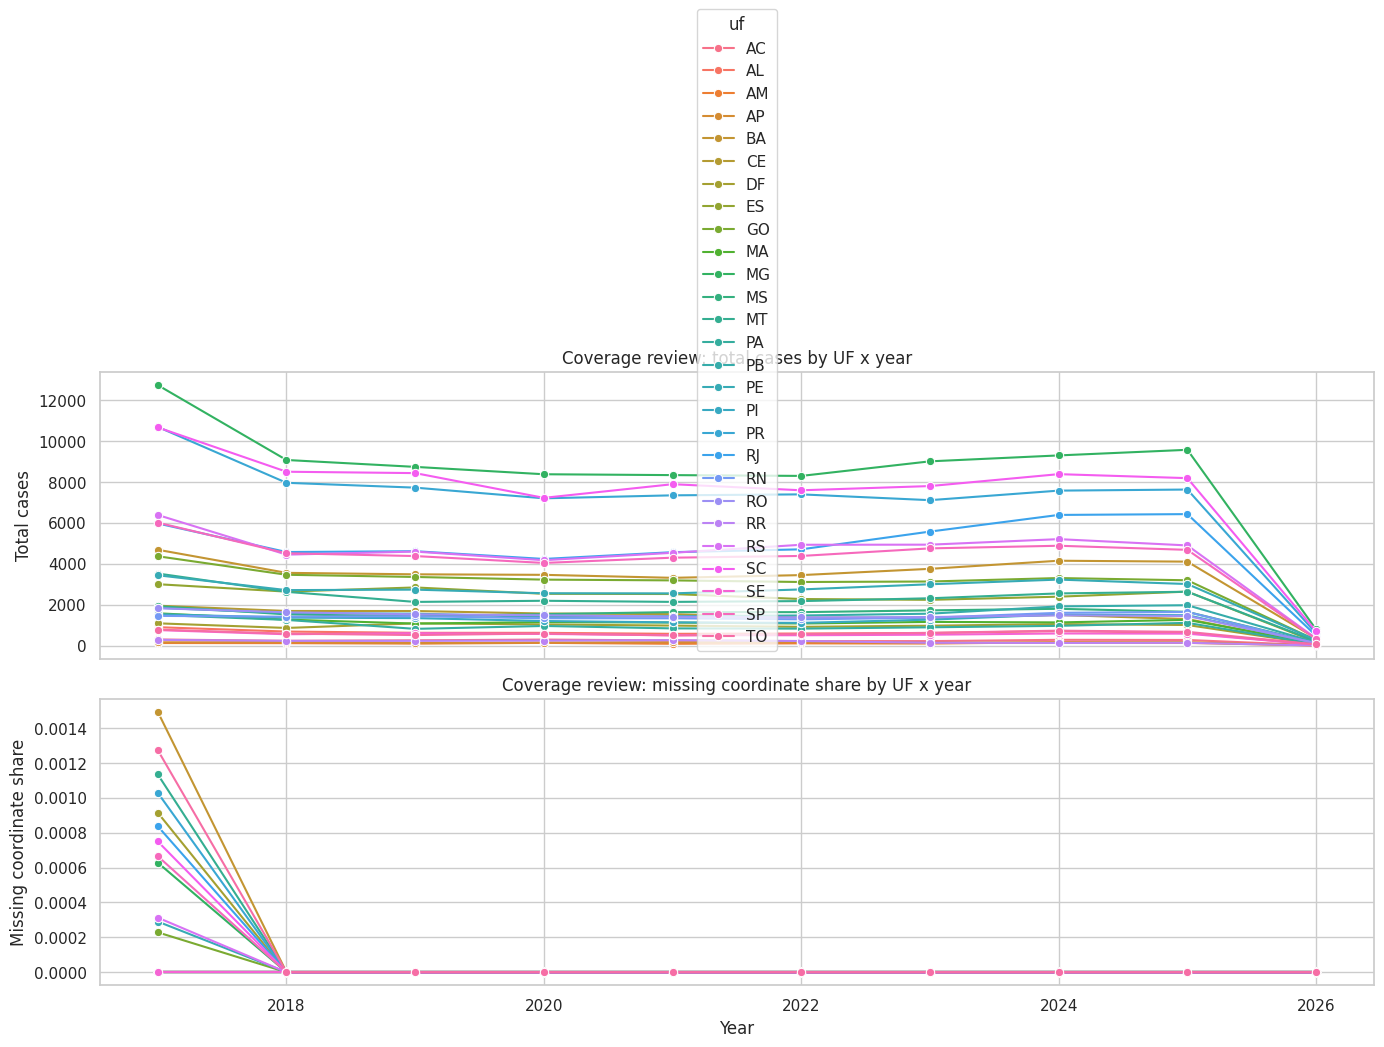

In [11]:
coverage_plot_df = coverage_review.loc[coverage_review["uf"].notna() & coverage_review["year"].notna()].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
sns.lineplot(
    data=coverage_plot_df,
    x="year",
    y="total_cases",
    hue="uf",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Coverage review: total cases by UF x year")
axes[0].set_ylabel("Total cases")

sns.lineplot(
    data=coverage_plot_df,
    x="year",
    y="missing_coords_share",
    hue="uf",
    marker="o",
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Coverage review: missing coordinate share by UF x year")
axes[1].set_ylabel("Missing coordinate share")
axes[1].set_xlabel("Year")

plt.tight_layout()
plt.show()

In [26]:
artifact_inventory = pd.DataFrame(
    {
        "artifact": [
            "occurrence_standardized",
            "br101_centerlines_by_snapshot",
            "br101_corridors_by_snapshot",
            "br101_centerline_union",
            "br101_corridor_union",
            "municipalities_in_scope",
            "rgis_in_scope",
            "road_sections_by_municipality",
            "road_sections_by_rgi",
            "accidents_classified",
            "manual_review_candidates",
            "canonical_accidents",
            "canonical_accidents_geospatial",
            "canonical_accidents_unmatched_assignments",
            "coverage_review_uf_year",
            "manual_exclusions",
        ],
        "path": [
            str(ARTIFACTS_DIR / "occurrence_standardized.parquet"),
            str(ARTIFACTS_DIR / "br101_centerlines_by_snapshot.parquet"),
            str(ARTIFACTS_DIR / "br101_corridors_by_snapshot.parquet"),
            str(ARTIFACTS_DIR / "br101_centerline_union.parquet"),
            str(ARTIFACTS_DIR / "br101_corridor_union.parquet"),
            str(ARTIFACTS_DIR / "municipalities_in_scope.parquet"),
            str(ARTIFACTS_DIR / "rgis_in_scope.parquet"),
            str(ARTIFACTS_DIR / "road_sections_by_municipality.parquet"),
            str(ARTIFACTS_DIR / "road_sections_by_rgi.parquet"),
            str(ARTIFACTS_DIR / "accidents_classified.parquet"),
            str(ARTIFACTS_DIR / "manual_review_candidates.parquet"),
            str(ARTIFACTS_DIR / "canonical_accidents.parquet"),
            str(ARTIFACTS_DIR / "canonical_accidents_geospatial.parquet"),
            str(ARTIFACTS_DIR / "canonical_accidents_unmatched_assignments.parquet"),
            str(ARTIFACTS_DIR / "coverage_review_uf_year.parquet"),
            str(ARTIFACTS_DIR / "manual_exclusions.parquet"),
        ],
    }
)
artifact_inventory

,artifact,path
0,occurrence_standardized,/home/arthur/Documents/projects/radar-prf-101/...
1,br101_centerlines_by_snapshot,/home/arthur/Documents/projects/radar-prf-101/...
2,br101_corridors_by_snapshot,/home/arthur/Documents/projects/radar-prf-101/...
3,br101_centerline_union,/home/arthur/Documents/projects/radar-prf-101/...
4,br101_corridor_union,/home/arthur/Documents/projects/radar-prf-101/...
5,municipalities_in_scope,/home/arthur/Documents/projects/radar-prf-101/...
6,rgis_in_scope,/home/arthur/Documents/projects/radar-prf-101/...
7,road_sections_by_municipality,/home/arthur/Documents/projects/radar-prf-101/...
8,road_sections_by_rgi,/home/arthur/Documents/projects/radar-prf-101/...
9,accidents_classified,/home/arthur/Documents/projects/radar-prf-101/...
